In [1]:
import matplotlib.pyplot as plt
import json

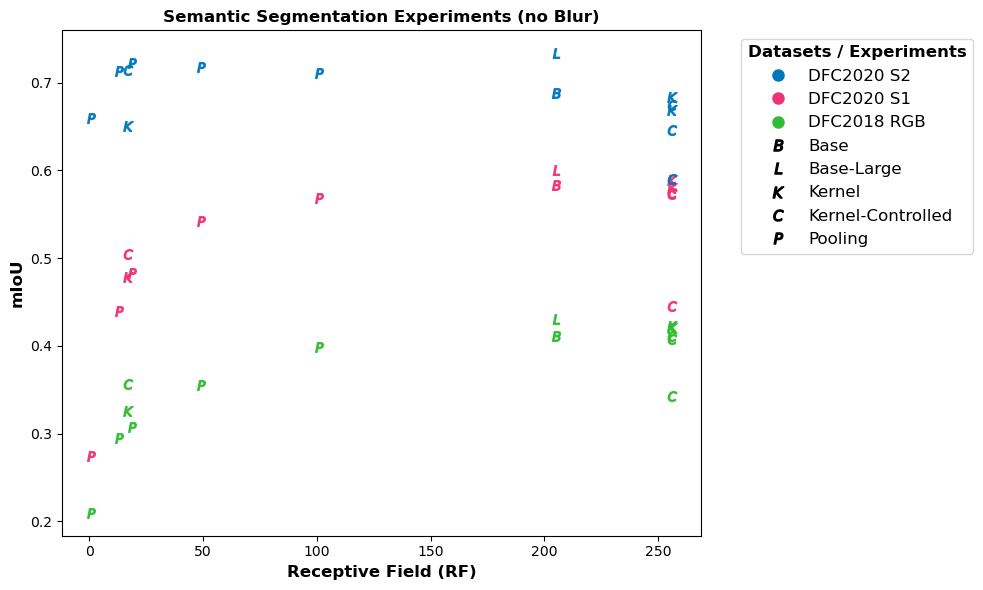

In [36]:
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load JSON
with open("segmentation_results_no_blur.json", "r") as f:
    data = json.load(f)

# Strong colors
dataset_colors = {
    "DFC2020 S2": "#0077BB",  # strong blue
    "DFC2020 S1": "#EE3377",  # strong red
    "DFC2018 RGB": "#33BB33"  # strong green
}

# Letters for experiments (math text)
exp_letters = {
    "B": "$B$",
    "L": "$L$",
    "K": "$K$",
    "C": "$C$",
    "P": "$P$"
}

# Experiment descriptions
exp_descriptions = {
    "B": "Base",
    "L": "Base-Large",
    "K": "Kernel",
    "C": "Kernel-Controlled",
    "P": "Pooling"
}

fig, ax = plt.subplots(figsize=(10, 6))

# Plot data points
for model in data:
    rf = model["RF"][0]       # x-axis
    miou = model["mIoU"]      # y-axis
    dataset = model["Data"]
    exp_type = model["ExpType"]

    ax.plot(
        rf, miou,
        marker=exp_letters.get(exp_type, "?"),
        color=dataset_colors[dataset],
        markersize=7,
        linestyle='None',
        alpha=0.9
    )

ax.set_xlabel("Receptive Field (RF)", fontweight="bold", fontsize=12)
ax.set_ylabel("mIoU", fontweight="bold", fontsize=12)
ax.set_title("Semantic Segmentation Experiments (no Blur)", fontweight="bold")

# --- Combined legend handles ---
# Dataset handles (colored circles)
dataset_handles = [
    Line2D([0], [0],
           marker='o',
           color=color,
           markersize=8,
           linestyle='None',
           label=name)
    for name, color in dataset_colors.items()
]

# Experiment handles (letters)
exp_handles = [
    Line2D([0], [0],
           marker=exp_letters[etype],
           color='black',  # letters black
           markersize=8,
           linestyle='None',
           label=f"{exp_descriptions[etype]}")
    for etype in exp_letters
]

# Combine handles
all_handles = dataset_handles + exp_handles

# Create one legend box
legend = ax.legend(handles=all_handles, title="Datasets / Experiments",
          bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12)
legend.get_title().set_fontsize(12)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
plt.show()


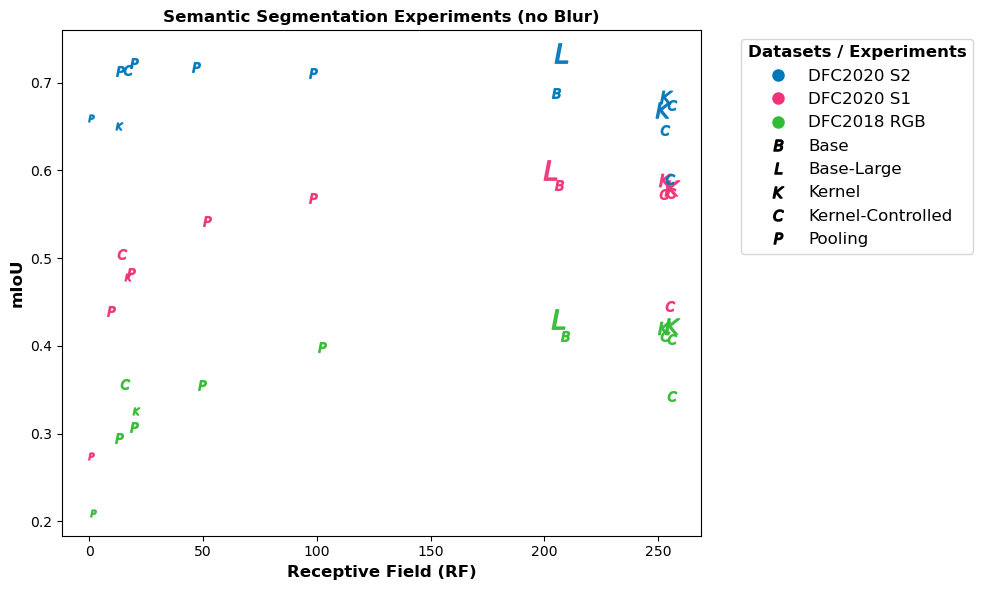

In [112]:
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Load JSON
with open("segmentation_results_no_blur.json", "r") as f:
    data = json.load(f)

# Strong colors
dataset_colors = {
    "DFC2020 S2": "#0077BB",  # strong blue
    "DFC2020 S1": "#EE3377",  # strong red
    "DFC2018 RGB": "#33BB33"  # strong green
}

# Letters for experiments (math text)
exp_letters = {
    "B": "$B$",
    "L": "$L$",
    "K": "$K$",
    "C": "$C$",
    "P": "$P$"
}

# Experiment descriptions
exp_descriptions = {
    "B": "Base",
    "L": "Base-Large",
    "K": "Kernel",
    "C": "Kernel-Controlled",
    "P": "Pooling"
}

fig, ax = plt.subplots(figsize=(10, 6))

# Plot data points with marker size based on ParamSetSize
for model in data:
    rf = model["RF"][0]       # x-axis
    miou = model["mIoU"]      # y-axis
    dataset = model["Data"]
    exp_type = model["ExpType"]
    param_size = model.get("SizeMB", 1)  # in MB, default 1 if missing

    # Add small random jitter to x-axis only
    rf = rf + np.random.uniform(-4, 4)  # adjust -0.5 to 0.5 as needed
    rf= np.clip(rf, 1, 256)

    # Map ParamSetSize to marker size
    if param_size < 1:
        ms = 5
    elif 1 <= param_size < 5:
        ms = 7
    elif 5 <= param_size < 10:
        ms = 9
    elif 10 <= param_size < 25:
        ms = 11
    else:  # >=25
        ms = 14

    ax.plot(
        rf, miou,
        marker=exp_letters.get(exp_type, "?"),
        color=dataset_colors[dataset],
        markersize=ms,
        linestyle='None',
        alpha=0.9
    )


ax.set_xlabel("Receptive Field (RF)", fontweight="bold", fontsize=12)
ax.set_ylabel("mIoU", fontweight="bold", fontsize=12)
ax.set_title("Semantic Segmentation Experiments (no Blur)", fontweight="bold")

# --- Combined legend handles ---
# Dataset handles (colored circles)
dataset_handles = [
    Line2D([0], [0],
           marker='o',
           color=color,
           markersize=8,
           linestyle='None',
           label=name)
    for name, color in dataset_colors.items()
]

# Experiment handles (letters)
exp_handles = [
    Line2D([0], [0],
           marker=exp_letters[etype],
           color='black',  # letters black
           markersize=8,
           linestyle='None',
           label=f"{exp_descriptions[etype]}")
    for etype in exp_letters
]

# Combine handles
all_handles = dataset_handles + exp_handles

# Create one legend box
legend = ax.legend(handles=all_handles, title="Datasets / Experiments",
          bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12)
legend.get_title().set_fontsize(12)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
plt.show()
